Libraries

In [3]:
# Import main libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Warning management
import warnings
warnings.filterwarnings("ignore")

# Plot configuration
plt.style.use("default")

Dataset Loading

In [4]:
# ================================
#  DATASET LOADING
# ================================

# Load CSV
df = pd.read_csv("/content/timeseries_lagged_dataset.csv", index_col=0)

# Display first rows
display(df.head())

# Dataset info
print("\nINFO DATASET:\n")
display(df.info())

display(df.columns)

,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11
timestamp,,,,,,,,,,,
2023-01-01 00:00:00,50.7451,NaN,107.3947,NaN,51.2402,NaN,197.0148,NaN,73.2979,NaN,43.7306
2023-01-01 01:00:00,50.5711,NaN,94.7684,NaN,49.9087,NaN,201.9429,NaN,74.0998,NaN,48.2869
2023-01-01 02:00:00,52.4755,NaN,101.0926,NaN,53.7170,NaN,203.4386,NaN,75.6723,NaN,56.4986
2023-01-01 03:00:00,54.4119,41.1013,106.2644,NaN,55.5596,NaN,208.0018,NaN,76.2139,NaN,46.4980
2023-01-01 04:00:00,52.2548,45.0555,102.3924,NaN,52.3654,NaN,208.8805,NaN,77.0501,NaN,44.9502



INFO DATASET:

<class 'pandas.core.frame.DataFrame'>
Index: 5040 entries, 2023-01-01 00:00:00 to 2023-07-29 23:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var1    4863 non-null   float64
 1   var2    4888 non-null   float64
 2   var3    4845 non-null   float64
 3   var4    4856 non-null   float64
 4   var5    4912 non-null   float64
 5   var6    4849 non-null   float64
 6   var7    4855 non-null   float64
 7   var8    4897 non-null   float64
 8   var9    4819 non-null   float64
 9   var10   4790 non-null   float64
 10  var11   4850 non-null   float64
dtypes: float64(11)
memory usage: 472.5+ KB


None

Index(['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9',
       'var10', 'var11'],
      dtype='object')

Timestamp Column Handing

In [5]:
# ================================
# TIMESTAMP INDEX CONVERSION
# ================================

# Convert index to datetime
df.index = pd.to_datetime(df.index)

# Sort by time
df = df.sort_index()

# Check result
print("Tipo indice:")
print(type(df.index))

print("\nPrime date:")
print(df.index[:5])

df = df.asfreq("H")


# ================================
# TEMPORAL FREQUENCY CHECK
# ================================

print("Frequenza attuale:")
print(df.index.freq)

print("\nIntervallo temporale:")
print(df.index.min(), "->", df.index.max())

Tipo indice:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

Prime date:
DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)
Frequenza attuale:
<Hour>

Intervallo temporale:
2023-01-01 00:00:00 -> 2023-07-29 23:00:00


Dataset Structure Analysis

In [6]:
# ================================
# DATASET STRUCTURE ANALYSIS
# ================================

# Dataset dimensions
print("Shape dataset:")
print(df.shape)

# Data types
print("\nTipi dati:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nStatistiche descrittive:")
print(df.describe())

Shape dataset:
(5040, 11)

Tipi dati:
var1     float64
var2     float64
var3     float64
var4     float64
var5     float64
var6     float64
var7     float64
var8     float64
var9     float64
var10    float64
var11    float64
dtype: object

Missing values:
var1     177
var2     152
var3     195
var4     184
var5     128
var6     191
var7     185
var8     143
var9     221
var10    250
var11    190
dtype: int64

Statistiche descrittive:
              var1         var2         var3         var4         var5  \
count  4863.000000  4888.000000  4845.000000  4856.000000  4912.000000   
mean     55.050470    46.772698    97.499500     0.077115    56.025307   
std       3.863082     4.165391     4.231172     5.950465     4.727300   
min      44.162100    34.269600    82.181000   -25.347500    42.781700   
25%      52.264300    43.853150    94.635900    -3.809150    52.669200   
50%      55.049500    46.822250    97.505100     0.009850    56.039100   
75%      57.813000    49.725075   100.354200

Missing values Handing

In [7]:
# ================================
# MISSING VALUES HANDLING
# ================================

# Missing values BEFORE
print("Missing values prima:")
print(df.isnull().sum())

# Forward fill
df = df.ffill()

# Backward fill as safety net
df = df.bfill()

# Missing values AFTER
print("\nMissing values dopo:")
print(df.isnull().sum())

Missing values prima:
var1     177
var2     152
var3     195
var4     184
var5     128
var6     191
var7     185
var8     143
var9     221
var10    250
var11    190
dtype: int64

Missing values dopo:
var1     0
var2     0
var3     0
var4     0
var5     0
var6     0
var7     0
var8     0
var9     0
var10    0
var11    0
dtype: int64


DETRENDING / DIFFERENCING

In [8]:
# ================================
# DIFFERENCING / DETRENDING
# ================================

# Apply first differencing
df_diff = df.diff()

# Remove NaN rows introduced by differencing
df_diff = df_diff.dropna()

# Check output
print("Prime righe dataset detrended:")
print(df_diff.head())

print("\nShape dataset detrended:")
print(df_diff.shape)

Prime righe dataset detrended:
                       var1    var2     var3  var4    var5  var6    var7  \
timestamp                                                                  
2023-01-01 01:00:00 -0.1740  0.0000 -12.6263   0.0 -1.3315   0.0  4.9281   
2023-01-01 02:00:00  1.9044  0.0000   6.3242   0.0  3.8083   0.0  1.4957   
2023-01-01 03:00:00  1.9364  0.0000   5.1718   0.0  1.8426   0.0  4.5632   
2023-01-01 04:00:00 -2.1571  3.9542  -3.8720   0.0 -3.1942   0.0  0.8787   
2023-01-01 05:00:00  0.3018  2.2264  -1.6947   0.0  0.0000   0.0  0.0000   

                     var8    var9  var10    var11  
timestamp                                          
2023-01-01 01:00:00   0.0  0.8019    0.0   4.5563  
2023-01-01 02:00:00   0.0  1.5725    0.0   8.2117  
2023-01-01 03:00:00   0.0  0.5416    0.0 -10.0006  
2023-01-01 04:00:00   0.0  0.8362    0.0  -1.5478  
2023-01-01 05:00:00   0.0  0.0000    0.0  -0.8208  

Shape dataset detrended:
(5039, 11)


PEARSON CORRELATION MATRIX

           var1      var2      var3      var4      var5      var6      var7  \
var1   1.000000  0.026558 -0.006652 -0.001808  0.841287 -0.006759  0.109849   
var2   0.026558  1.000000  0.013198 -0.003641  0.020741  0.017698  0.044515   
var3  -0.006652  0.013198  1.000000 -0.004233  0.006628  0.020686  0.005106   
var4  -0.001808 -0.003641 -0.004233  1.000000  0.012580  0.011450 -0.006381   
var5   0.841287  0.020741  0.006628  0.012580  1.000000 -0.008728  0.089943   
var6  -0.006759  0.017698  0.020686  0.011450 -0.008728  1.000000 -0.006329   
var7   0.109849  0.044515  0.005106 -0.006381  0.089943 -0.006329  1.000000   
var8  -0.007488  0.015761 -0.006812 -0.001151 -0.002382  0.022998  0.016745   
var9  -0.025450 -0.010516 -0.015869  0.025522 -0.019011  0.004455  0.009813   
var10 -0.002526  0.033850 -0.003133 -0.006862 -0.013090 -0.019553 -0.002676   
var11 -0.003029 -0.029811 -0.005225 -0.002593 -0.013153 -0.012226 -0.001590   

           var8      var9     var10     var11  
var

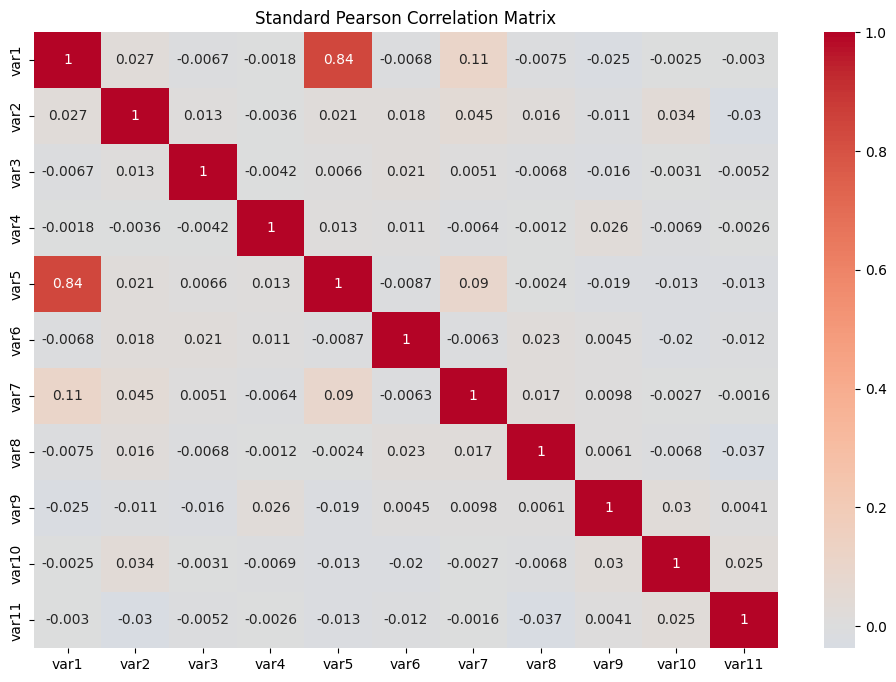

In [9]:
# ================================
# STANDARD CORRELATION MATRIX
# ================================

# Compute Pearson correlation matrix
corr_standard = df_diff.corr()

# Display matrix
print(corr_standard)

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_standard,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standard Pearson Correlation Matrix")
plt.show()

LAG-AWARE CORRELATION ENGINE

In [10]:
# ================================
# LAG-AWARE CORRELATION ENGINE
# ================================

def compute_lagged_correlations(df, max_lag=10):

    # Variable list
    columns = df.columns

    # Best correlations matrix
    best_corr_matrix = pd.DataFrame(
        index=columns,
        columns=columns
    )

    # Best lags matrix
    best_lag_matrix = pd.DataFrame(
        index=columns,
        columns=columns
    )

    # Iterate over all variable pairs
    for col1 in columns:

        for col2 in columns:

            # Temporary variables
            best_corr = 0
            best_lag = 0

            # Test all lags
            for lag in range(-max_lag, max_lag + 1):

                # Shift the second variable
                shifted_series = df[col2].shift(lag)

                # Compute correlation
                corr = df[col1].corr(shifted_series)

                # Check validity
                if pd.notna(corr):

                    # Keep the highest absolute correlation
                    if abs(corr) > abs(best_corr):

                        best_corr = corr
                        best_lag = lag

            # Store results
            best_corr_matrix.loc[col1, col2] = best_corr
            best_lag_matrix.loc[col1, col2] = best_lag

    return (
        best_corr_matrix.astype(float),
        best_lag_matrix.astype(int)
    )

LAG-AWARE CORRELATION ENGINE -- EXECUTION

In [11]:
# ================================
# RUN LAG ENGINE
# ================================

# Compute lag-aware matrices
corr_matrix, lag_matrix = compute_lagged_correlations(
    df_diff,
    max_lag=24
)

# Output correlations
print("BEST CORRELATION MATRIX")
print(corr_matrix)

# Output lag
print("\nBEST LAG MATRIX")
print(lag_matrix)

BEST CORRELATION MATRIX
           var1      var2      var3      var4      var5      var6      var7  \
var1   1.000000  0.440333 -0.036812  0.035942  0.841287  0.291632 -0.150776   
var2   0.440333  1.000000 -0.039538  0.043342  0.384130  0.121008 -0.078349   
var3  -0.036812 -0.039538  1.000000 -0.463063  0.033027 -0.025619 -0.030160   
var4   0.035942  0.043342 -0.463063  1.000000 -0.033030  0.037627 -0.036837   
var5   0.841287  0.384130  0.033027 -0.033030  1.000000  0.256473 -0.136911   
var6   0.291632  0.121008 -0.025619  0.037627  0.256473  1.000000  0.056741   
var7  -0.150776 -0.078349 -0.030160 -0.036837 -0.136911  0.056741  1.000000   
var8   0.043647 -0.032600  0.094855  0.035037  0.049614  0.035437  0.050357   
var9   0.031484 -0.035249  0.038840 -0.046234  0.030655 -0.056025  0.034466   
var10 -0.039563 -0.052684  0.035930  0.043012 -0.043601 -0.042104  0.036792   
var11 -0.041053  0.039523 -0.037034  0.043715 -0.037836 -0.061174 -0.048501   

           var8      var9  

COMBINED MATRIX

In [12]:
# ================================
# FINAL COMBINED MATRIX
# ================================

# Round correlations
corr_rounded = corr_matrix.round(3)

# Build combined matrix
combined_matrix = (
    corr_rounded.astype(str)
    + " | lag="
    + lag_matrix.astype(str)
)

# Visualization
print(combined_matrix)

                   var1             var2              var3              var4  \
var1        1.0 | lag=0    0.44 | lag=-3   -0.037 | lag=21    0.036 | lag=16   
var2       0.44 | lag=3      1.0 | lag=0    -0.04 | lag=-4    0.043 | lag=19   
var3   -0.037 | lag=-21    -0.04 | lag=4       1.0 | lag=0   -0.463 | lag=-5   
var4    0.036 | lag=-16  0.043 | lag=-19    -0.463 | lag=5       1.0 | lag=0   
var5      0.841 | lag=0   0.384 | lag=-3     0.033 | lag=2   -0.033 | lag=12   
var6      0.292 | lag=6    0.121 | lag=3    -0.026 | lag=3    0.038 | lag=-2   
var7    -0.151 | lag=12   -0.078 | lag=9    -0.03 | lag=-9    -0.037 | lag=2   
var8      0.044 | lag=4  -0.033 | lag=-5    0.095 | lag=10    0.035 | lag=19   
var9      0.031 | lag=4  -0.035 | lag=-3   0.039 | lag=-18  -0.046 | lag=-21   
var10    -0.04 | lag=21   -0.053 | lag=1   0.036 | lag=-18   0.043 | lag=-14   
var11   -0.041 | lag=18    0.04 | lag=13  -0.037 | lag=-15   0.044 | lag=-20   

                   var5              va

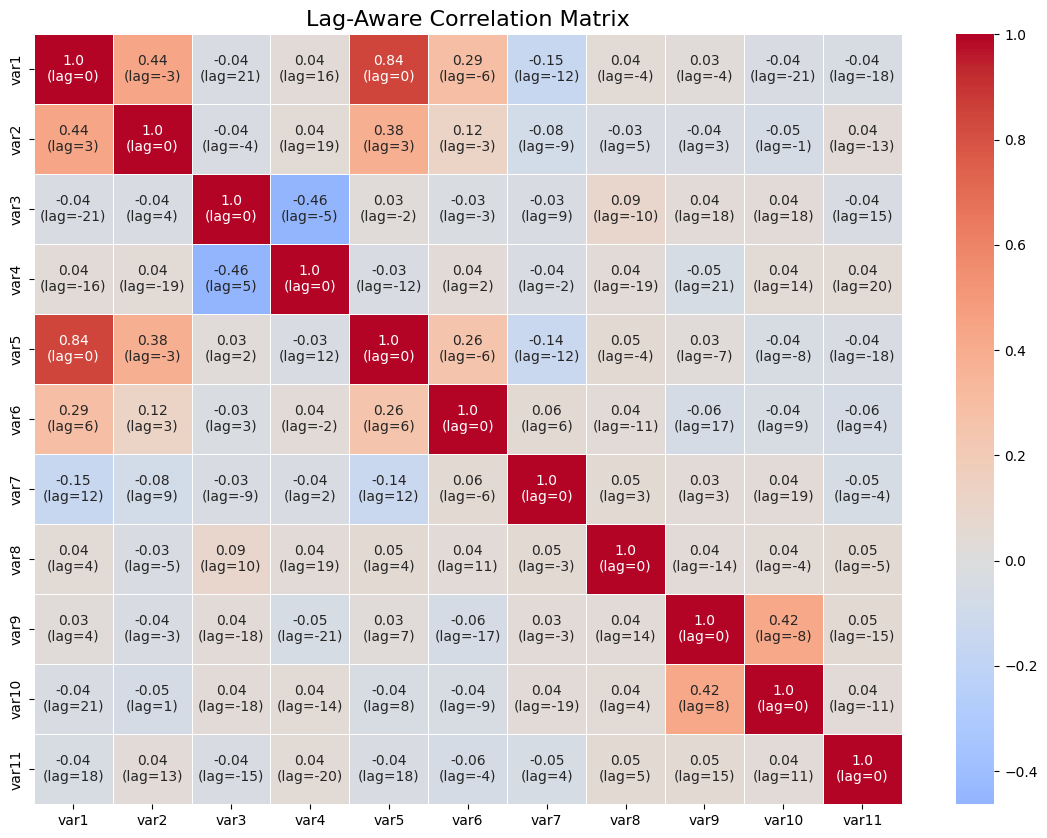

In [13]:
# ================================
# LAG-AWARE HEATMAP
# ================================

# Build text annotations
annotations = corr_matrix.round(2).astype(str)

annotations = (
    annotations
    + "\n(lag="
    + lag_matrix.astype(str)
    + ")"
)

# Create figure
plt.figure(figsize=(14, 10))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=annotations,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

# Title
plt.title(
    "Lag-Aware Correlation Matrix",
    fontsize=16
)

plt.show()